# ASNE Contrast Explorer

Research cockpit for ASNE binary contrast experiments. This notebook inspects existing contrast evaluation summaries, compares scoring methods, shows failure cases, and summarizes which contrast axes are currently separable.

ASNE outputs are predicted response similarities from frozen neural encoding models. They are not emotion detection, diagnosis, or measurement of an individual person's mental state.


## Current Interpretation

Current evidence suggests the ASNE text/TTS pipeline separates semantic or logical contrasts better than motion-style text contrasts.

Known results so far:

- `contradiction_vs_consistency_paired` with `centroid_raw`: `5/6 = 0.83`
- `expected_vs_unexpected_paired` with `centroid_raw`: `5/6 = 0.83`
- `approach_vs_static_paired` with `centroid_raw`: `3/6 = 0.50`
- `cause_effect_valid_vs_invalid_paired` with `centroid_raw`: `5/6 = 0.83`

Practical binary contrast setting for text/TTS experiments:

```text
signature = mean_response
aggregation = centroid
scoring = centroid_raw
```

`paired_vote` is useful diagnostically, but it has not beaten `centroid_raw` on the current expected/unexpected run. `approach_vs_static` is weak in text/TTS and may require video stimuli because it is closer to a motion/perception contrast.


In [1]:
from pathlib import Path
import os
import sys


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "asne").exists():
            return candidate
    fallback = Path("/Users/hikaru/ASNE")
    if fallback.exists():
        return fallback
    raise RuntimeError("Could not find ASNE repo root. Launch Jupyter from /Users/hikaru/ASNE.")


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
src_path = str(REPO_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print("Repo root:", REPO_ROOT)
print("Outputs exist:", Path("outputs/asne_evals/contrasts").exists())

import pandas as pd
import matplotlib.pyplot as plt

from asne.notebook_utils import (
    best_methods_by_contrast,
    compact_contrast_table,
    executive_summary_lines,
    compute_response_norm_timeline,
    compute_segment_similarity_timeline,
    compute_transition_norm_timeline,
    extract_failures,
    get_top_moving_dimensions,
    load_mean_response_category_centroids,
    load_raw_segments,
    load_summary,
    load_summary_rows,
    load_temporal_summary_rows,
    plot_contrast_scores,
    summaries_to_dataframe,
)

SUMMARY_ROOT = Path("outputs/asne_evals/contrasts")
TEMPORAL_SUMMARY_ROOT = Path("outputs/asne_temporal_evals")
rows = load_summary_rows(SUMMARY_ROOT)

if not rows:
    print(f"No contrast summaries found under {SUMMARY_ROOT}. Run an evaluation first.")
else:
    print(f"Found {len(rows)} contrast summary files under {SUMMARY_ROOT}.")


Repo root: /Users/hikaru/ASNE
Outputs exist: True
Found 11 contrast summary files under outputs/asne_evals/contrasts.


## Executive Summary

This is the high-level readout. It shows the best currently available scoring result per contrast and flags promising versus weak axes.


In [2]:
if not rows:
    print('No contrast summaries found yet.')
else:
    print('\n'.join(executive_summary_lines(rows)))
    display(compact_contrast_table(rows))


ASNE Contrast Executive Summary

Best available result per contrast:
- approach_vs_static_paired: 3/6 top-1 = 0.50 using centroid_raw
- contradiction_vs_consistency: 3/6 top-1 = 0.50 using full
- contradiction_vs_consistency_mini: 2/4 top-1 = 0.50 using full
- contradiction_vs_consistency_paired: 5/6 top-1 = 0.83 using centroid_raw
- expected_vs_unexpected_paired: 5/6 top-1 = 0.83 using centroid_raw

Current practical setting: signature=mean_response, aggregation=centroid, scoring=centroid_raw.
Weak or unresolved axes: approach_vs_static_paired, contradiction_vs_consistency, contradiction_vs_consistency_mini.
Promising axes: contradiction_vs_consistency_paired, expected_vs_unexpected_paired.

Interpretation: these are predicted response-similarity results, not emotion detection, diagnosis, or measurement of a person's mental state.


,contrast_name,scoring_mode,score,top2_accuracy,mean_rank_expected,timestamp
0,approach_vs_static_paired,centroid_raw,3/6 (0.50),1.0,1.500000,20260521T000101Z
1,contradiction_vs_consistency,full,3/6 (0.50),1.0,1.500000,20260519T192832Z
2,contradiction_vs_consistency_mini,full,2/4 (0.50),1.0,1.500000,20260519T220749Z
3,contradiction_vs_consistency_paired,centroid_raw,5/6 (0.83),1.0,1.166667,20260520T233908Z
4,expected_vs_unexpected_paired,centroid_raw,5/6 (0.83),1.0,1.166667,20260521T003012Z


## Full Artifact Table

This table keeps the detailed paths and per-category accuracy fields for audit/debug use. The executive summary above is the easier first read.


In [3]:
df = summaries_to_dataframe(rows)
if df.empty:
    print('No summary rows available.')
else:
    display(df[[
        'contrast_name',
        'timestamp',
        'scoring_mode',
        'signature_mode',
        'aggregation_mode',
        'top1_correct',
        'total',
        'top1_accuracy',
        'top2_accuracy',
        'mean_rank_expected',
        'per_category_accuracy',
        'summary_path',
        'failure_report_path',
    ]])


,contrast_name,timestamp,scoring_mode,signature_mode,aggregation_mode,top1_correct,total,top1_accuracy,top2_accuracy,mean_rank_expected,per_category_accuracy,summary_path,failure_report_path
0,contradiction_vs_consistency_paired,20260520T233908Z,centroid_raw,delta_from_neutral,centroid,5,6,0.833333,1.0,1.166667,"{'consistent_information': {'correct': 2, 'tot...",outputs/asne_evals/contrasts/contradiction_vs_...,outputs/asne_evals/contrasts/contradiction_vs_...
1,expected_vs_unexpected_paired,20260521T003012Z,centroid_raw,mean_response,centroid,5,6,0.833333,1.0,1.166667,"{'expected_outcome': {'correct': 2, 'total': 3...",outputs/asne_evals/contrasts/expected_vs_unexp...,outputs/asne_evals/contrasts/expected_vs_unexp...
2,expected_vs_unexpected_paired,20260521T005815Z,centroid_raw,mean_response,centroid,5,6,0.833333,1.0,1.166667,"{'expected_outcome': {'correct': 2, 'total': 3...",outputs/asne_evals/contrasts/expected_vs_unexp...,outputs/asne_evals/contrasts/expected_vs_unexp...
3,contradiction_vs_consistency_paired,20260520T203253Z,full,delta_from_neutral,centroid,4,6,0.666667,1.0,1.333333,"{'consistent_information': {'correct': 1, 'tot...",outputs/asne_evals/contrasts/contradiction_vs_...,outputs/asne_evals/contrasts/contradiction_vs_...
4,contradiction_vs_consistency_paired,20260520T233753Z,binary_axis,delta_from_neutral,centroid,4,6,0.666667,1.0,1.333333,"{'consistent_information': {'correct': 1, 'tot...",outputs/asne_evals/contrasts/contradiction_vs_...,outputs/asne_evals/contrasts/contradiction_vs_...
5,expected_vs_unexpected_paired,20260521T003836Z,paired_vote,mean_response,centroid,4,6,0.666667,1.0,1.333333,"{'expected_outcome': {'correct': 2, 'total': 3...",outputs/asne_evals/contrasts/expected_vs_unexp...,outputs/asne_evals/contrasts/expected_vs_unexp...
6,approach_vs_static_paired,20260521T000101Z,centroid_raw,mean_response,centroid,3,6,0.500000,1.0,1.500000,"{'static_scene': {'correct': 1, 'total': 3, 'a...",outputs/asne_evals/contrasts/approach_vs_stati...,outputs/asne_evals/contrasts/approach_vs_stati...
7,approach_vs_static_paired,20260521T001012Z,full,delta_from_neutral,centroid,3,6,0.500000,1.0,1.500000,"{'static_scene': {'correct': 0, 'total': 3, 'a...",outputs/asne_evals/contrasts/approach_vs_stati...,outputs/asne_evals/contrasts/approach_vs_stati...
8,approach_vs_static_paired,20260521T001121Z,binary_axis,delta_from_neutral,centroid,3,6,0.500000,1.0,1.500000,"{'static_scene': {'correct': 1, 'total': 3, 'a...",outputs/asne_evals/contrasts/approach_vs_stati...,outputs/asne_evals/contrasts/approach_vs_stati...
9,contradiction_vs_consistency,20260519T192832Z,full,delta_from_neutral,centroid,3,6,0.500000,1.0,1.500000,"{'consistent_information': {'correct': 1, 'tot...",outputs/asne_evals/contrasts/contradiction_vs_...,outputs/asne_evals/contrasts/contradiction_vs_...


## Method Comparison

This view selects the best scoring method per contrast using top-1 accuracy, then top-2 accuracy, then mean expected rank. The current practical recommendation for binary text/TTS semantic contrasts is `centroid_raw`.


In [4]:
best_df = best_methods_by_contrast(rows)
if best_df.empty:
    print('No method comparison available.')
else:
    display(best_df[[
        'contrast_name',
        'scoring_mode',
        'signature_mode',
        'aggregation_mode',
        'top1_accuracy',
        'top2_accuracy',
        'mean_rank_expected',
        'summary_path',
    ]])


,contrast_name,scoring_mode,signature_mode,aggregation_mode,top1_accuracy,top2_accuracy,mean_rank_expected,summary_path
0,approach_vs_static_paired,centroid_raw,mean_response,centroid,0.500000,1.0,1.500000,outputs/asne_evals/contrasts/approach_vs_stati...
1,contradiction_vs_consistency,full,delta_from_neutral,centroid,0.500000,1.0,1.500000,outputs/asne_evals/contrasts/contradiction_vs_...
2,contradiction_vs_consistency_mini,full,delta_from_neutral,centroid,0.500000,1.0,1.500000,outputs/asne_evals/contrasts/contradiction_vs_...
3,contradiction_vs_consistency_paired,centroid_raw,delta_from_neutral,centroid,0.833333,1.0,1.166667,outputs/asne_evals/contrasts/contradiction_vs_...
4,expected_vs_unexpected_paired,centroid_raw,mean_response,centroid,0.833333,1.0,1.166667,outputs/asne_evals/contrasts/expected_vs_unexp...


## Failure Inspection

Set `selected_summary_path` to any summary JSON path from the table above. The helper prints failed examples, expected versus predicted categories, rank, score gap, and full ranking.


In [5]:
selected_summary_path = None

if selected_summary_path is None and not df.empty:
    selected_summary_path = df.iloc[0]['summary_path']

if selected_summary_path is None:
    print('No summary selected.')
else:
    summary = load_summary(selected_summary_path)
    print('Selected:', selected_summary_path)
    failures = extract_failures(summary)
    if not failures:
        print('No top-1 failures in this summary.')
    for failure in failures:
        print('---')
        print('id:', failure['id'])
        print('input:', failure['input_text'])
        print('expected:', failure['expected_category'])
        print('predicted:', failure['predicted_category'])
        print('rank_of_expected:', failure['rank_of_expected'])
        print('score_gap:', failure['score_gap'])
        print('ranking:')
        for index, item in enumerate(failure['ranking'], start=1):
            score = item.get('score', item.get('centroid_cosine_similarity', item.get('vote_count')))
            print(f'  {index}. {item.get("category")} score={score}')


Selected: outputs/asne_evals/contrasts/contradiction_vs_consistency_paired/20260520T233908Z_summary.json
---
id: eval_paired_consistent_information_02
input: Someone reads that the parcel goes on Shelf C7. The inventory screen also says Shelf C7.
expected: consistent_information
predicted: contradictory_information
rank_of_expected: 2
score_gap: 0.0017760279781650068
ranking:
  1. contradictory_information score=0.9820803061218468
  2. consistent_information score=0.9803042781436818


## Contrast Comparison Charts

Each chart uses matplotlib only, one chart per figure, with default colors.


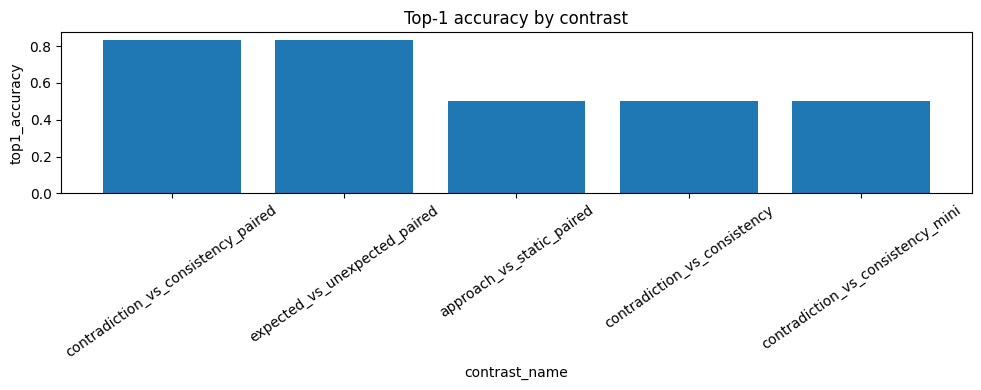

In [6]:
if df.empty:
    print('No charts available because no summaries were found.')
else:
    plot_contrast_scores(df, metric='top1_accuracy', title='Top-1 accuracy by contrast')
    plt.show()


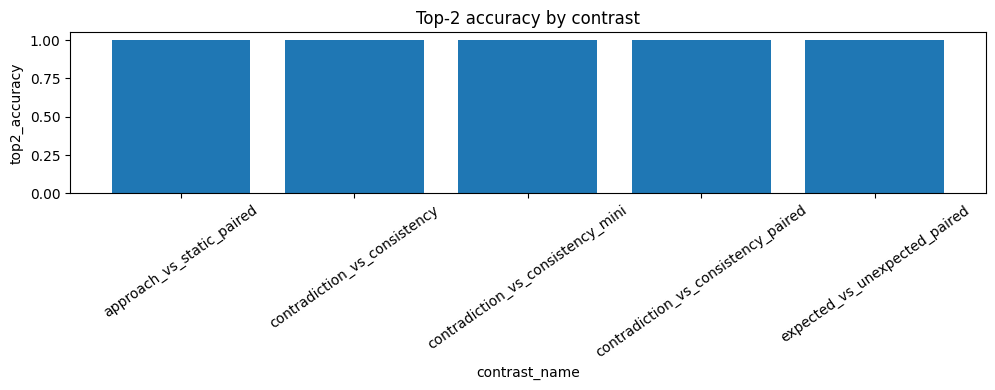

In [7]:
if df.empty:
    print('No charts available because no summaries were found.')
else:
    plot_contrast_scores(df, metric='top2_accuracy', title='Top-2 accuracy by contrast')
    plt.show()


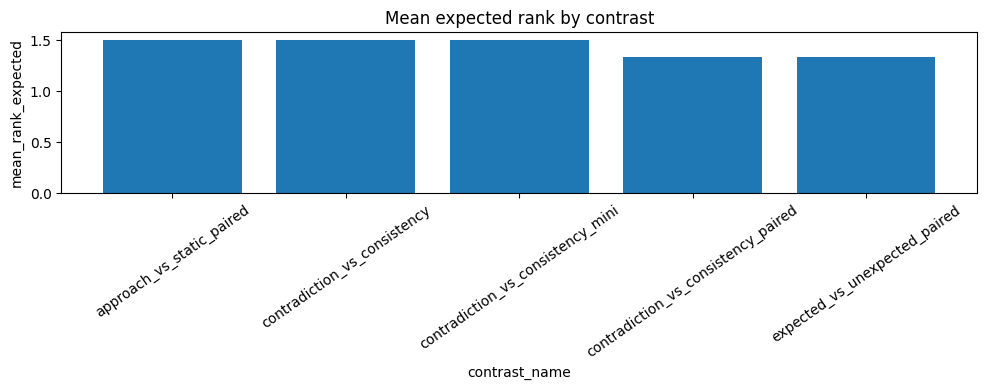

In [8]:
if df.empty:
    print('No charts available because no summaries were found.')
else:
    plot_contrast_scores(df, metric='mean_rank_expected', title='Mean expected rank by contrast')
    plt.show()


## Temporal Eval Summary

This section loads outputs from `scripts/evaluate_asne_temporal_contrast.py` and compares mean-response accuracy with early, late, final-segment, and majority segment winners.

Current temporal readout from paired binary contrasts:

| contrast | mean_response_acc | early_acc | late_acc | final_segment_acc | majority_segment_acc | avg_switch_count | recovered_mean_failures |
|---|---:|---:|---:|---:|---:|---:|---:|
| `contradiction_vs_consistency_paired` | 0.83 | 0.50 | 0.83 | 0.83 | 0.83 | 1.33 | 1 |
| `approach_vs_static_paired` | 0.50 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0 |
| `expected_vs_unexpected_paired` | 0.83 | 0.50 | 0.83 | 1.00 | 0.83 | 0.50 | 1 |
| `cause_effect_valid_vs_invalid_paired` | 0.83 | 0.50 | 0.83 | 0.67 | 0.67 | 1.00 | 1 |

Temporal segment-level analysis can expose predicted response shifts hidden by whole-stimulus mean response. On `expected_vs_unexpected_paired`, final-segment scoring reached `6/6`. This remains predicted stimulus-response similarity, not emotion detection, diagnosis, or measurement of a person's mental state.


In [ ]:
temporal_rows = load_temporal_summary_rows(TEMPORAL_SUMMARY_ROOT)
if not temporal_rows:
    print(f'No temporal eval summaries found under {TEMPORAL_SUMMARY_ROOT}. Run scripts/evaluate_asne_temporal_contrast.py first.')
else:
    temporal_df = pd.DataFrame(temporal_rows).sort_values(['late_accuracy', 'final_segment_accuracy', 'majority_segment_accuracy'], ascending=[False, False, False])
    temporal_df['recovered_mean_failures'] = temporal_df['examples_where_mean_failed_but_temporal_succeeded'].apply(len)
    display(temporal_df[['contrast_name', 'timestamp', 'total_examples', 'mean_response_accuracy', 'early_accuracy', 'late_accuracy', 'final_segment_accuracy', 'majority_segment_accuracy', 'average_switch_count', 'recovered_mean_failures']])


In [ ]:
if temporal_rows:
    for row in temporal_rows:
        if row['examples_where_mean_failed_but_late_succeeded']:
            print(row['contrast_name'], 'mean failed but late succeeded:', row['examples_where_mean_failed_but_late_succeeded'])
        if row['examples_with_category_shift']:
            print(row['contrast_name'], 'category shifts:', row['examples_with_category_shift'])


## Temporal Movement Diagnostics

This section inspects one saved stimulus output at the segment level. It uses saved raw TRIBE segment predictions to show response norm over time, transition movement, segment-level similarity to category centroids, and the dimensions with the largest predicted temporal movement. These plots are diagnostics for predicted response similarity only.


In [ ]:
# Pick one stimulus output JSON. Change these paths to inspect another dictionary or eval artifact.
dictionary_index = Path('outputs/asne_dictionaries/expected_vs_unexpected_paired_tts_macos_say_samantha_180/dictionary_index.json')
candidate_stimuli = sorted(dictionary_index.parent.glob('*.json')) if dictionary_index.exists() else []
candidate_stimuli = [path for path in candidate_stimuli if path.name != 'dictionary_index.json']
stimulus_output = candidate_stimuli[0] if candidate_stimuli else None

if stimulus_output is None:
    print('No stimulus output JSON found. Build a dictionary first, then rerun this cell.')
else:
    print('Dictionary:', dictionary_index)
    print('Stimulus:', stimulus_output)


In [ ]:
if stimulus_output is None:
    raw_segments = None
    print('No temporal diagnostics available yet.')
else:
    raw_segments = load_raw_segments(stimulus_output)
    category_centroids = load_mean_response_category_centroids(dictionary_index)
    response_norm = compute_response_norm_timeline(raw_segments)
    transition_norm = compute_transition_norm_timeline(raw_segments)
    segment_similarity = compute_segment_similarity_timeline(raw_segments, category_centroids, metric='cosine')
    top_moving = get_top_moving_dimensions(raw_segments, k=20)
    print('Raw segment shape:', raw_segments.shape)
    print('Segments:', raw_segments.shape[0])


In [ ]:
if raw_segments is not None:
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(range(len(response_norm)), response_norm, marker='o')
    ax.set_title('Response norm per segment')
    ax.set_xlabel('segment')
    ax.set_ylabel('L2 norm')
    fig.tight_layout()
    plt.show()


In [ ]:
if raw_segments is not None:
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(range(1, len(transition_norm) + 1), transition_norm, marker='o')
    ax.set_title('Transition movement norm per segment')
    ax.set_xlabel('transition ending at segment')
    ax.set_ylabel('L2 norm of step delta')
    fig.tight_layout()
    plt.show()


In [ ]:
if raw_segments is not None:
    sim_df = pd.DataFrame(segment_similarity['similarities'], columns=segment_similarity['categories'])
    sim_df.insert(0, 'segment', segment_similarity['segments'])
    display(sim_df)
    fig, ax = plt.subplots(figsize=(8, 3))
    for category in segment_similarity['categories']:
        ax.plot(sim_df['segment'], sim_df[category], marker='o', label=category)
    ax.set_title('Segment-level similarity to category centroids')
    ax.set_xlabel('segment')
    ax.set_ylabel('cosine similarity')
    ax.legend()
    fig.tight_layout()
    plt.show()


In [ ]:
if raw_segments is not None:
    print('Top dimensions by absolute net movement')
    display(pd.DataFrame(top_moving['net_movement']))
    print('Top dimensions by absolute total movement')
    display(pd.DataFrame(top_moving['abs_total_movement']))


## Helper Function Examples

These functions are imported from `asne.notebook_utils`:

```python
summary = load_summary('outputs/asne_evals/contrasts/.../<timestamp>_summary.json')
row = summarize_summary(summary)
failures = extract_failures(summary)
fig = plot_contrast_scores(df, metric='top1_accuracy')
```


## Command Examples

Run a binary contrast evaluation with the current practical setting:

```bash
TOKENIZERS_PARALLELISM=false HF_HUB_OFFLINE=1 TRANSFORMERS_OFFLINE=1 \
python scripts/evaluate_asne_dictionary.py \
  --dictionary outputs/asne_dictionaries/expected_vs_unexpected_paired_tts_macos_say_samantha_180/dictionary_index.json \
  --eval data/stimuli/evals/contrasts/expected_vs_unexpected_paired_eval.json \
  --tribev2-package-path ./tribev2 \
  --cache-folder ./cache \
  --feature-device cpu \
  --tts-backend macos_say \
  --signature mean_response \
  --aggregation centroid \
  --scoring centroid_raw \
  --debug-traceback
```

Run diagnostic paired voting:

```bash
TOKENIZERS_PARALLELISM=false HF_HUB_OFFLINE=1 TRANSFORMERS_OFFLINE=1 \
python scripts/evaluate_asne_dictionary.py \
  --dictionary outputs/asne_dictionaries/expected_vs_unexpected_paired_tts_macos_say_samantha_180/dictionary_index.json \
  --eval data/stimuli/evals/contrasts/expected_vs_unexpected_paired_eval.json \
  --tribev2-package-path ./tribev2 \
  --cache-folder ./cache \
  --feature-device cpu \
  --tts-backend macos_say \
  --signature mean_response \
  --aggregation centroid \
  --scoring paired_vote \
  --debug-traceback
```

Generate a failure diagnostic report from an existing summary:

```bash
python scripts/analyze_asne_eval_failures.py \
  --summary outputs/asne_evals/contrasts/expected_vs_unexpected_paired/20260521T003012Z_summary.json
```


## Notes

Use this notebook to inspect reproducible ASNE output artifacts. Report results as predicted response-similarity behavior of the current text/TTS pipeline. Do not interpret these outputs as direct neural measurements, emotion detection, diagnosis, or measurement of any person's mental state.
